# Bass普及モデル — ModelingToolkit.jl によるシミュレーション

## Bassモデルとは

Frank Bass (1969) が提唱した新製品普及の微分方程式モデル。

$$\frac{dN}{dt} = \underbrace{p \cdot (M - N)}_{\text{イノベーター}} + \underbrace{q \cdot \frac{N}{M} \cdot (M - N)}_{\text{イミテーター}}$$

| 記号 | 意味 |
|------|------|
| $N(t)$ | 累積採用者数 |
| $M$ | 市場ポテンシャル（最終的な採用者総数） |
| $p$ | イノベーション係数（外部影響：広告など） |
| $q$ | イミテーション係数（内部影響：口コミ） |

- **$p$ が大きい** → 早期から採用が広がる（広告主導型）
- **$q$ が大きい** → 口コミで爆発的に広がるが初期は遅い（口コミ主導型）

In [55]:
using ModelingToolkit
using ModelingToolkit: t_nounits as t, D_nounits as D
using DifferentialEquations
using Plots
using LaTeXStrings
#gr(fontfamily="PlemolJP-Text")

In [69]:
# Plots 日本語フォント設定
ENV["GKS_ENCODING"] = "utf8"
gr(fontfamily="PlemolJP-Text")

Plots.GRBackend()

## 1. モデル定義

In [12]:
# パラメータ・変数の宣言
@parameters p q M
@variables N(t)   # 累積採用者数
@variables n(t)   # 期間ごとの新規採用者数（observable）

# Bass モデルの方程式
eqs = [
    D(N) ~ (p + q * N / M) * (M - N),  # 微分方程式
    n    ~ (p + q * N / M) * (M - N)   # n は dN/dt と同じ（観測量として定義）
]

@named bass = ODESystem(eqs, t)
sys = mtkcompile(bass)

Model bass:
Equations (1):
  1 standard: see equations(bass)
Unknowns (1): see unknowns(bass)
  N(t)
Parameters (3): see parameters(bass)
  M
  p
  q
Observed (1): see observed(bass)

## 2. 基本シミュレーション

典型的なパラメータ（家電製品などの実測値に近い値）

In [13]:
# 初期条件・パラメータ設定
tspan = (0.0, 20.0)   # 20期間

# Dict 形式で初期値とパラメータをまとめて渡す（推奨形式）
prob = ODEProblem(sys,
    Dict(N => 0.0, p => 0.03, q => 0.38, M => 1000.0),
    tspan)
sol  = solve(prob, Tsit5(); saveat = 0.1)

println("最終採用者数: ", round(sol[N][end], digits=1), " / ", 1000.0)

最終採用者数: 996.2 / 1000.0


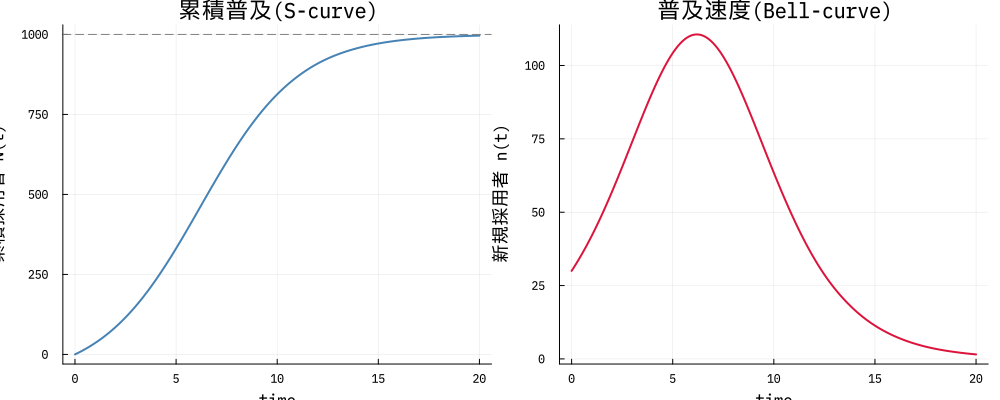

In [70]:
# S字カーブ（累積普及）と普及速度（ベル型）を並べて描画
p1 = plot(sol.t, sol[N],
    xlabel = "time", ylabel = "累積採用者 N(t)",
    title  = "累積普及(S-curve)",
    lw = 2, color = :steelblue, legend = false)
hline!(p1, [1000.0], lw=1, ls=:dash, color=:gray, label="M")

p2 = plot(sol.t, sol[n],
    xlabel = "time", ylabel = "新規採用者 n(t)",
    title  = "普及速度(Bell-curve)",
    lw = 2, color = :crimson, legend = false)

plot(p1, p2, layout = (1, 2), size = (1000, 400))

## 3. パラメータ感度分析 — イミテーション係数 q の影響

q が大きいほど口コミ効果が強く、ピークが高く・早くなる

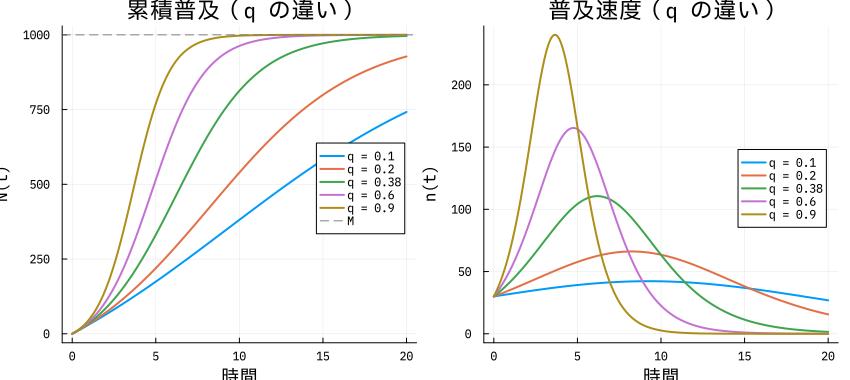

In [41]:
q_values = [0.1, 0.2, 0.38, 0.6, 0.9]

plt_N = plot(title="累積普及（q の違い）", xlabel="時間", ylabel="N(t)")
plt_n = plot(title="普及速度（q の違い）", xlabel="時間", ylabel="n(t)")

for qi in q_values
    prob_i = ODEProblem(sys,
        Dict(N => 0.0, p => 0.03, q => qi, M => 1000.0),
        tspan)
    sol_i = solve(prob_i, Tsit5(); saveat = 0.1)
    label_i = "q = $qi"
    plot!(plt_N, sol_i.t, sol_i[N]; lw=2, label=label_i)
    plot!(plt_n, sol_i.t, sol_i[n]; lw=2, label=label_i)
end

hline!(plt_N, [1000.0]; lw=1, ls=:dash, color=:gray, label="M")
plot(plt_N, plt_n, layout=(1,2), size=(850, 380), legend=:right)

## 4. パラメータ感度分析 — イノベーション係数 p の影響

p が大きいほど広告・外部刺激の効果が強く、初期から普及が進む

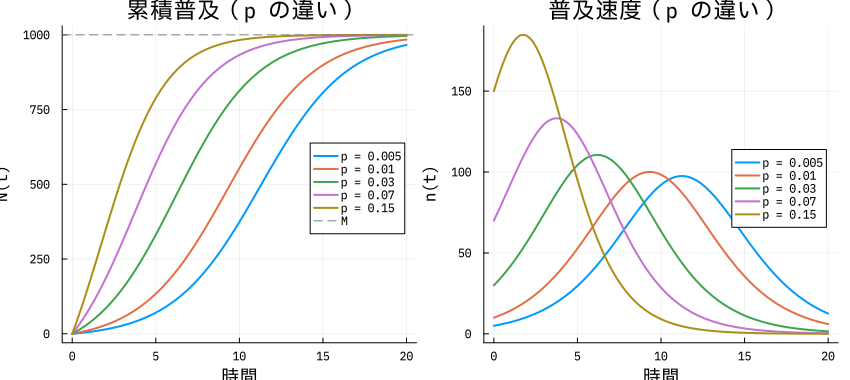

In [46]:
p_values = [0.005, 0.01, 0.03, 0.07, 0.15]

plt_N2 = plot(title="累積普及（p の違い）", xlabel="時間", ylabel="N(t)")
plt_n2 = plot(title="普及速度（p の違い）", xlabel="時間", ylabel="n(t)")

for pi_val in p_values
    prob_i = ODEProblem(sys,
        Dict(N => 0.0, p => pi_val, q => 0.38, M => 1000.0),
        tspan)
    sol_i = solve(prob_i, Tsit5(); saveat = 0.1)
    label_i = "p = $pi_val"
    plot!(plt_N2, sol_i.t, sol_i[N]; lw=2, label=label_i)
    plot!(plt_n2, sol_i.t, sol_i[n]; lw=2, label=label_i)
end

hline!(plt_N2, [1000.0]; lw=1, ls=:dash, color=:gray, label="M")
plot(plt_N2, plt_n2, layout=(1,2), size=(850, 380), legend=:right)

## 5. 拡張 Bass モデル — 広告投下量の時変効果

イノベーション係数 p を時間関数として変化させる。

$$\frac{dN}{dt} = \left( p(t) + q \cdot \frac{N}{M} \right)(M - N)$$

ここでは `@register_symbolic` で外部関数 `adstock(t)` を組み込む。

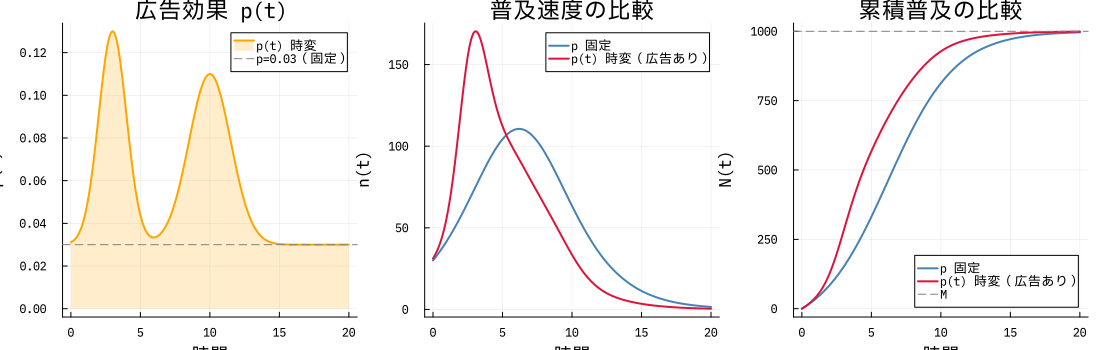

In [42]:
# 広告効果（キャンペーン期間だけ p が上昇するイメージ）
function adstock_p(t_val)
    base   = 0.03
    burst  = 0.1  * exp(-0.5 * ((t_val -  3.0) / 1.0)^2)  # t=3 にキャンペーンピーク
    burst2 = 0.08 * exp(-0.5 * ((t_val - 10.0) / 1.5)^2)  # t=10 に再投下
    return base + burst + burst2
end

@register_symbolic adstock_p(t)

@parameters q2 M2
@variables N2(t) n2(t) pt(t)

eqs2 = [
    D(N2) ~ (adstock_p(t) + q2 * N2 / M2) * (M2 - N2),
    n2    ~ (adstock_p(t) + q2 * N2 / M2) * (M2 - N2),
    pt    ~ adstock_p(t)   # 広告効果の時系列を観測量として記録
]

@named bass_ad = ODESystem(eqs2, t)
sys2 = mtkcompile(bass_ad)

prob2 = ODEProblem(sys2,
    Dict(N2 => 0.0, q2 => 0.38, M2 => 1000.0),
    tspan)
sol2 = solve(prob2, Tsit5(); saveat = 0.1)

# 比較用：固定 p のソリューション（prob は上で定義済み）
sol_base = solve(prob, Tsit5(); saveat = 0.1)

# 描画
pA = plot(sol2.t, sol2[pt],
    title="広告効果 p(t)", xlabel="時間", ylabel="p(t)",
    lw=2, color=:orange, label="p(t) 時変",
    fill=(0, 0.2, :orange))
hline!(pA, [0.03]; lw=1, ls=:dash, color=:gray, label="p=0.03（固定）")

pB = plot(sol_base.t, sol_base[n],
    title="普及速度の比較", xlabel="時間", ylabel="n(t)",
    lw=2, color=:steelblue, label="p 固定")
plot!(pB, sol2.t, sol2[n2]; lw=2, color=:crimson, label="p(t) 時変（広告あり）")

pC = plot(sol_base.t, sol_base[N],
    title="累積普及の比較", xlabel="時間", ylabel="N(t)",
    lw=2, color=:steelblue, label="p 固定")
plot!(pC, sol2.t, sol2[N2]; lw=2, color=:crimson, label="p(t) 時変（広告あり）")
hline!(pC, [1000.0]; lw=1, ls=:dash, color=:gray, label="M")

plot(pA, pB, pC, layout=(1,3), size=(1100, 350))

## 6. 複数セグメント合成モデル

市場を「早期採用者（アーリー）」と「遅延採用者（レイト）」の2セグメントに分割し、
それぞれ独立したBassモデルとして定義してから `compose` で合成する。

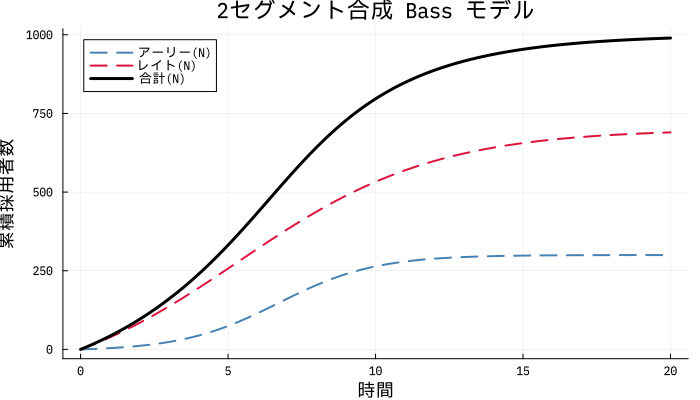

In [43]:
# セグメント別 Bass コンポーネントを関数で定義
function BassSegment(; name, p_default=0.03, q_default=0.38, M_default=500.0)
    @parameters p=p_default q=q_default M=M_default
    @variables N(t)=0.0 n(t)
    eqs = [
        D(N) ~ (p + q * N / M) * (M - N),
        n    ~ (p + q * N / M) * (M - N)
    ]
    return ODESystem(eqs, t, [N, n], [p, q, M]; name)
end

# 2セグメント（アーリーは口コミ強め、レイトはイノベーション強め）
@named early = BassSegment(p_default=0.01, q_default=0.6,  M_default=300.0)
@named late  = BassSegment(p_default=0.05, q_default=0.25, M_default=700.0)

# 合計採用者数を追加変数として合成
@variables N_total(t)
combined_eqs = [N_total ~ early.N + late.N]

@named combined = ODESystem(combined_eqs, t; systems=[early, late])
combined_sys = mtkcompile(combined)

# 初期値はデフォルト（N=0.0）が定義済みなので空の Dict で OK
prob3 = ODEProblem(combined_sys, Dict(), tspan)
sol3  = solve(prob3, Tsit5(); saveat=0.1)

# 描画
plot(
    sol3.t, [sol3[early.N] sol3[late.N] sol3[N_total]],
    label  = ["アーリー(N)" "レイト(N)" "合計(N)"],
    lw     = [2 2 3],
    ls     = [:dash :dash :solid],
    color  = [:steelblue :crimson :black],
    title  = "2セグメント合成 Bass モデル",
    xlabel = "時間", ylabel = "累積採用者数",
    size   = (700, 400)
)

In [36]:
ENV["GKS_ENCODING"] = "utf8"
gr(fontfamily="PlemolJP-Text")

Plots.GRBackend()

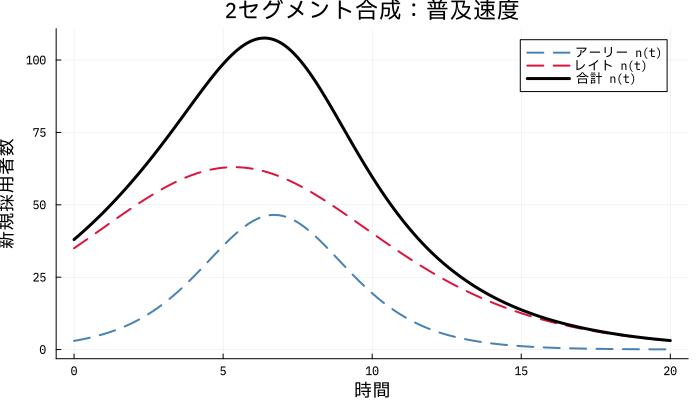

In [37]:
# 普及速度（ベル曲線）の比較
plot(
    sol3.t, [sol3[early.n] sol3[late.n] (sol3[early.n] .+ sol3[late.n])],
    label  = ["アーリー n(t)" "レイト n(t)" "合計 n(t)"],
    lw     = [2 2 3],
    ls     = [:dash :dash :solid],
    color  = [:steelblue :crimson :black],
    title  = "2セグメント合成：普及速度",
    xlabel = "時間", ylabel = "新規採用者数",
    size   = (700, 400)
)

## 7. p・q の位相空間でのピーク時刻マップ

p と q を振ったときに「普及のピーク（n最大）がいつ来るか」をヒートマップで確認する。

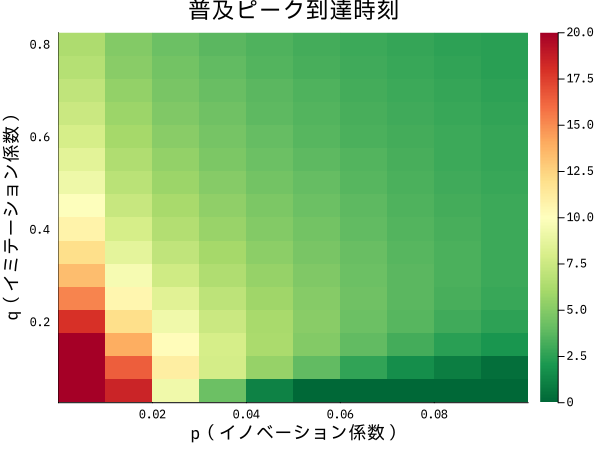

In [45]:
p_grid = 0.005:0.01:0.10
q_grid = 0.05:0.05:0.80

peak_times = zeros(length(q_grid), length(p_grid))

for (j, pj) in enumerate(p_grid)
    for (i, qi) in enumerate(q_grid)
        prob_ij = ODEProblem(sys,
            Dict(N => 0.0, p => pj, q => qi, M => 1000.0),
            tspan)
        sol_ij = solve(prob_ij, Tsit5(); saveat = 0.1)
        n_vals = sol_ij[n]
        peak_times[i, j] = sol_ij.t[argmax(n_vals)]
    end
end

heatmap(collect(p_grid), collect(q_grid), peak_times,
    xlabel = "p（イノベーション係数）",
    ylabel = "q（イミテーション係数）",
    title  = "普及ピーク到達時刻",
    color  = cgrad(:RdYlGn, rev=true),
    size   = (600, 450)
)

---

## まとめ

| モデル | 特徴 |
|--------|------|
| 基本 Bass | `D(N) ~ (p + q*N/M)*(M-N)` |
| 広告時変 p(t) | `@register_symbolic` で任意関数を埋め込み |
| 2セグメント合成 | `BassSegment` コンポーネント + `compose` |
| 感度分析 | `remake(prob; p=...)` でパラメータを差し替え |

**参考文献:** Bass, F. M. (1969). A new product growth for model consumer durables. *Management Science*, 15(5), 215-227.

## 8. ベイズパラメータ推定 — Turing.jl で p・q を同定する

スマートフォン普及率の実測値（2010〜2024年、総務省）を Bass モデルに当てはめ、  
ベイズ推定（NUTS サンプリング）でパラメータの事後分布を求める。

| パラメータ | 意味 | 事前分布 |
|------------|------|---------|
| `p` | イノベーション係数 | $\text{Truncated-Normal}(0.02,\, 0.02)$ |
| `q` | イミテーション係数 | $\text{Truncated-Normal}(0.30,\, 0.20)$ |
| `M` | 市場ポテンシャル（%） | $\text{Truncated-Normal}(100,\, 5)$ |
| `σ` | 観測ノイズ（%） | $\text{Exponential}(3)$ |

初期値は 2010 年の観測値（4.4%）を固定し、2011〜2024 年の 14 点で尤度を評価する。

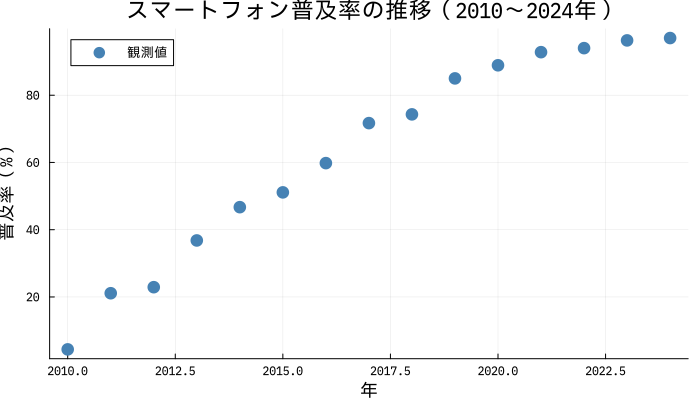

In [71]:
# スマートフォン普及率データ（総務省 情報通信白書）
years_obs = 2010:2024
obs_rate  = [4.4, 21.1, 22.9, 36.8, 46.7, 51.1, 59.8, 71.7, 74.3, 85.0, 88.9, 92.8, 94.0, 96.3, 97.0]
t_obs     = Float64.(0:14)    # 2010 → t=0, 2024 → t=14

scatter(collect(years_obs), obs_rate;
    xlabel = "年", ylabel = "普及率（%）",
    title  = "スマートフォン普及率の推移（2010〜2024年）",
    label  = "観測値", ms = 7, color = :steelblue,
    markerstrokewidth = 0, size = (700, 400))

In [72]:
using Turing

# Bass モデルの ODE（MTK を介さず直接定義して Turing と連携）
function bass_ode!(du, u, params, t)
    p_v, q_v, M_v = params
    N = u[1]
    du[1] = (p_v + q_v * N / M_v) * (M_v - N)
end

@model function bass_bayes(t_data, y_data)
    # 事前分布
    p_v ~ truncated(Normal(0.02, 0.02); lower = 1e-4, upper = 0.5)
    q_v ~ truncated(Normal(0.30, 0.20); lower = 1e-4, upper = 2.0)
    M_v ~ truncated(Normal(100.0, 5.0); lower = maximum(y_data) + 0.1, upper = 115.0)
    σ   ~ Exponential(3.0)

    N0 = y_data[1]   # 初期値：2010年の観測値（4.4%）を固定

    # ODE を解く
    prob_ode = ODEProblem(bass_ode!, [N0], (t_data[1], t_data[end]), [p_v, q_v, M_v])
    sol = solve(prob_ode, Tsit5(); saveat = t_data, abstol = 1e-6, reltol = 1e-6)

    # 求解失敗時は -Inf を加算してスキップ
    if !SciMLBase.successful_retcode(sol)
        Turing.@addlogprob! -Inf
        return
    end

    N_pred = sol[1, :]

    # 尤度（N0 は IC として使用済みなので i=2 から）
    for i in 2:length(y_data)
        y_data[i] ~ Normal(N_pred[i], σ)
    end
end

model_bass = bass_bayes(t_obs, obs_rate)
println("モデル定義完了")

モデル定義完了


In [73]:
# NUTS サンプリング（1000 サンプル）
setprogress!(true)
chain_bass = sample(model_bass, NUTS(0.65), 1000)

describe(chain_bass)

[ Info: [Turing]: progress logging is enabled globally
┌ Info: Found initial step size
└   ϵ = 0.025
Sampling: 100%|█████████████████████████████████████████| Time: 0:00:06


Chains MCMC chain (1000×18×1 Array{Float64, 3}):

Iterations        = 501:1:1500
Number of chains  = 1
Samples per chain = 1000
Wall duration     = 20.36 seconds
Compute duration  = 20.36 seconds
parameters        = p_v, q_v, M_v, σ
internals         = n_steps, is_accept, acceptance_rate, log_density, hamiltonian_energy, hamiltonian_energy_error, max_hamiltonian_energy_error, tree_depth, numerical_error, step_size, nom_step_size, logprior, loglikelihood, logjoint

Summary Statistics

  parameters       mean       std      mcse   ess_bulk   ess_tail      rhat    ⋯
      Symbol    Float64   Float64   Float64    Float64    Float64   Float64    ⋯

         p_v     0.0694    0.0117    0.0008   232.2961   467.7350    1.0161    ⋯
         q_v     0.2548    0.0542    0.0041   174.5030   321.2692    1.0185    ⋯
         M_v   102.1595    2.9883    0.1996   197.8418   273.3315    1.0115    ⋯
           σ     3.5324    0.8274    0.0530   253.4462   264.9082    1.0137    ⋯

                       

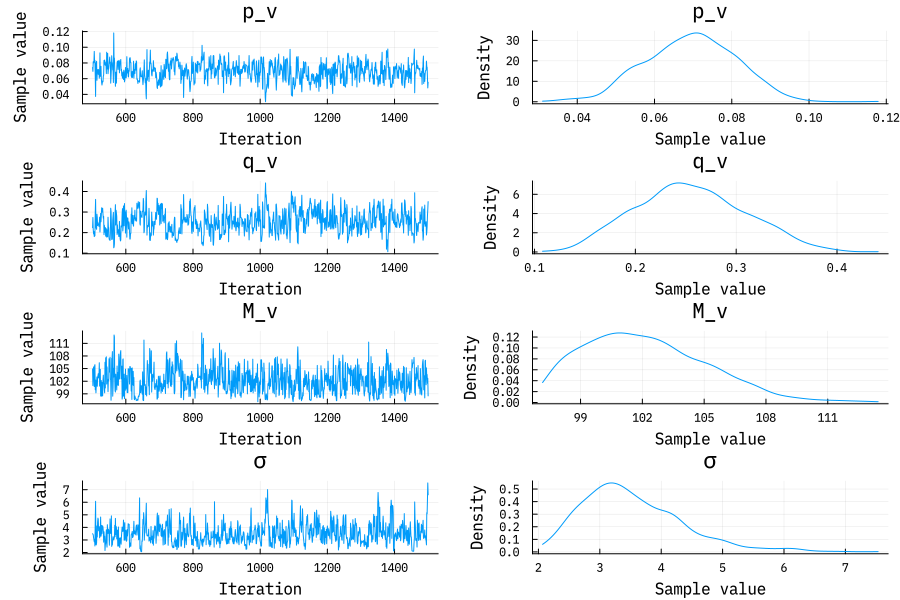

In [74]:
# 事後分布の可視化（トレースプロット + 周辺事後分布）
using StatsPlots

plot(chain_bass[[:p_v, :q_v, :M_v, :σ]];
    left_margin = 5Plots.mm, size = (900, 600))

推定パラメータ（事後平均）:
  p = 0.06938   ← イノベーション係数
  q = 0.2548   ← イミテーション係数
  M = 102.16 % ← 市場ポテンシャル


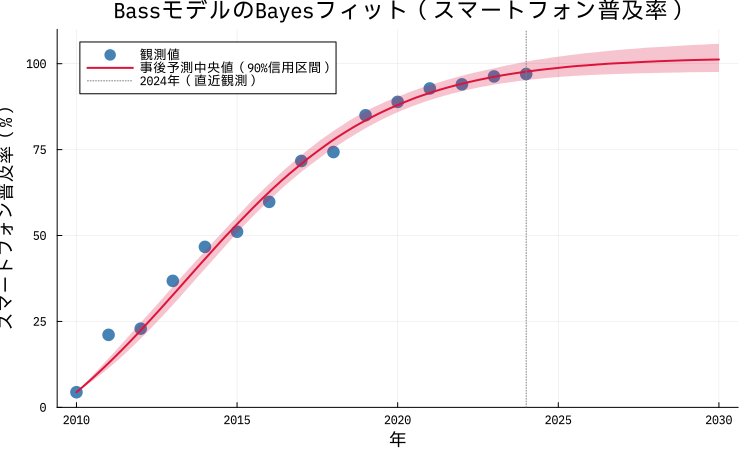

In [75]:
# 事後予測：推定曲線と不確実性バンド
using Statistics

N0_val     = obs_rate[1]
t_fine     = collect(0.0:0.1:20.0)
years_fine = 2010.0 .+ t_fine

p_samp = vec(chain_bass[:p_v])
q_samp = vec(chain_bass[:q_v])
M_samp = vec(chain_bass[:M_v])
n_samp = length(p_samp)

pred_mat = fill(NaN, n_samp, length(t_fine))

for i in 1:n_samp
    sol_i = solve(
        ODEProblem(bass_ode!, [N0_val], (t_fine[1], t_fine[end]),
                   [p_samp[i], q_samp[i], M_samp[i]]),
        Tsit5(); saveat = t_fine, abstol = 1e-6, reltol = 1e-6)
    if SciMLBase.successful_retcode(sol_i)
        pred_mat[i, :] = sol_i[1, :]
    end
end

# 列ごとに NaN を除いて分位点を計算
med_pred = [median(filter(!isnan, pred_mat[:, j])) for j in 1:length(t_fine)]
lo_pred  = [quantile(filter(!isnan, pred_mat[:, j]), 0.05) for j in 1:length(t_fine)]
hi_pred  = [quantile(filter(!isnan, pred_mat[:, j]), 0.95) for j in 1:length(t_fine)]

# 事後平均パラメータ
p_mean = mean(p_samp); q_mean = mean(q_samp); M_mean = mean(M_samp)

plt_fit = scatter(collect(years_obs), obs_rate;
    label = "観測値", ms = 7, color = :steelblue, markerstrokewidth = 0)
plot!(plt_fit, years_fine, med_pred;
    ribbon   = (med_pred .- lo_pred, hi_pred .- med_pred),
    fillalpha = 0.25, lw = 2, color = :crimson,
    label  = "事後予測中央値（90%信用区間）",
    xlabel = "年", ylabel = "スマートフォン普及率（%）",
    title  = "BassモデルのBayesフィット（スマートフォン普及率）",
    ylims  = (0, 110), size = (750, 450))

vline!(plt_fit, [2024]; lw = 1, ls = :dot, color = :gray, label = "2024年（直近観測）")

println("推定パラメータ（事後平均）:")
println("  p = $(round(p_mean, digits=5))   ← イノベーション係数")
println("  q = $(round(q_mean, digits=4))   ← イミテーション係数")
println("  M = $(round(M_mean, digits=2)) % ← 市場ポテンシャル")
plt_fit